In [ ]:
import numpy as np


def compute_dot_product_custom(vector_x, vector_y):
    total_sum = 0
    for x_val, y_val in zip(vector_x, vector_y):
        total_sum += x_val * y_val
    return total_sum

def compute_dot_product_numpy(vector_x, vector_y):
    return np.dot(vector_x, vector_y)


def calculate_euclidean_norm_custom(vector_x):
    squared_sum = 0
    for value in vector_x:
        squared_sum += value ** 2
    return squared_sum ** 0.5


def calculate_euclidean_norm_numpy(vector_x):
    return np.linalg.norm(vector_x)


def main():
    dimensions = int(input("Enter number of dimensions: "))

    print("Enter elements of vector X :")
    vector_x = list(map(float, input().split()))

    print("Enter elements of vector Y :")
    vector_y = list(map(float, input().split()))

    if len(vector_x) != dimensions or len(vector_y) != dimensions:
        print("Error: Number of elements must match the given dimension.")
        return

    custom_dot = compute_dot_product_custom(vector_x, vector_y)
    numpy_dot = compute_dot_product_numpy(vector_x, vector_y)

    print("\nResults of Dot Product:")
    print("Dot product manually :", custom_dot)
    print("Dot product using NumPy:", numpy_dot)


    custom_norm = calculate_euclidean_norm_custom(vector_x)
    numpy_norm = calculate_euclidean_norm_numpy(vector_x)

    print("\nResults of Euclidean Norm (Vector X):")
    print("Euclidean norm manually :", custom_norm)
    print("Euclidean norm using NumPy:", numpy_norm)

if __name__ == "__main__":
    main()



Enter elements of vector X :
Enter elements of vector Y :

Results of Dot Product:
Dot product manually : 20.0
Dot product using NumPy: 20.0

Results of Euclidean Norm (Vector X):
Euclidean norm manually : 3.7416573867739413
Euclidean norm using NumPy: 3.7416573867739413


In [8]:
import pandas as pd
import numpy as np

def calculate_mean(values):
    return np.mean(values)

def calculate_variance(values):
    return np.var(values)

def calculate_std_dev(values):
    return np.std(values)

def get_dataset_stats(features):
    mean_vals = np.mean(features, axis=0)
    variance_vals = np.var(features, axis=0)
    std_vals = np.std(features, axis=0)
    return mean_vals, variance_vals, std_vals

def get_class_center_and_spread(features, targets, label_name):
    class_data = features[targets == label_name]
    center = np.mean(class_data, axis=0)
    spread = np.std(class_data, axis=0)
    return center, spread

def find_distance_between_classes(center_a, center_b):
    return np.linalg.norm(center_a - center_b)

def main():
    data_frame = pd.read_excel("Lab Session Data.xlsx", sheet_name="Purchase data")

    features = data_frame[['Candies (#)', 'Mangoes (Kg)', 'Milk Packets (#)']].values
    targets = data_frame['Payment (Rs)'].apply(lambda amount: "RICH" if amount > 200 else "POOR").values

    dataset_mean, dataset_variance, dataset_std = get_dataset_stats(features)

    rich_center, rich_spread = get_class_center_and_spread(features, targets, "RICH")
    poor_center, poor_spread = get_class_center_and_spread(features, targets, "POOR")

    class_distance = find_distance_between_classes(rich_center, poor_center)

    print("Dataset Mean:", dataset_mean)
    print("Dataset Variance:", dataset_variance)
    print("Dataset Std Dev:", dataset_std)

    print("\nCenter (RICH):", rich_center)
    print("Spread (RICH):", rich_spread)

    print("\nCenter (POOR):", poor_center)
    print("Spread (POOR):", poor_spread)

    print("\nDistance Between Classes:", class_distance)

if __name__ == "__main__":
    main()

Dataset Mean: [19.8  3.2  3.1]
Dataset Variance: [13.16  3.36  2.09]
Dataset Std Dev: [3.62767143 1.83303028 1.44568323]

Center (RICH): [20.          4.5         2.66666667]
Spread (RICH): [4.28174419 1.11803399 1.49071198]

Center (POOR): [19.5   1.25  3.75]
Spread (POOR): [2.29128785 0.4330127  1.08972474]

Distance Between Classes: 3.4620963463068315


Mean: 19.8
Variance: 13.16


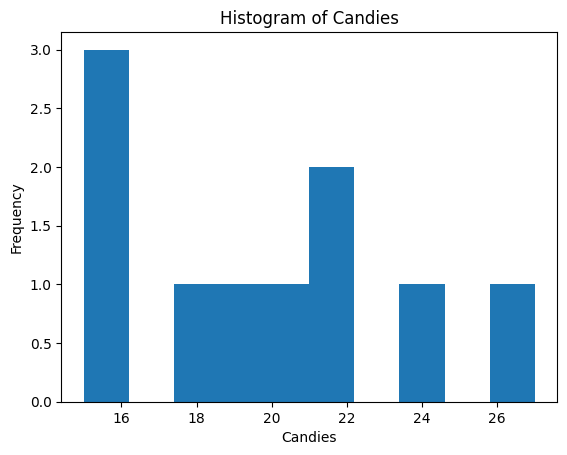

In [10]:
# A3 : Histogram, Mean and Variance of a Feature

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def load_feature(file_path):
    df = pd.read_excel(file_path, sheet_name="Purchase data")
    return df['Candies (#)'].values   # taking ONE feature


def calculate_mean(data):
    return np.mean(data)


def calculate_variance(data):
    return np.var(data)


def plot_histogram(data):
    hist, bins = np.histogram(data, bins=10)
    
    plt.hist(data, bins=10)
    plt.xlabel("Candies")
    plt.ylabel("Frequency")
    plt.title("Histogram of Candies")
    plt.show()

    return hist, bins


def main():
    file_path = "Lab Session Data.xlsx"

    feature = load_feature(file_path)

    mean_value = calculate_mean(feature)
    variance_value = calculate_variance(feature)

    print("Mean:", mean_value)
    print("Variance:", variance_value)

    plot_histogram(feature)


if __name__ == "__main__":
    main()


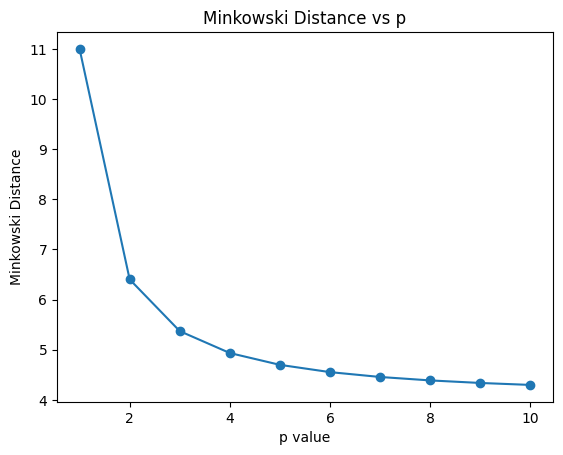

In [11]:
# A4

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def minkowski_distance(v1, v2, p):
    total = 0
    for i in range(len(v1)):
        total += abs(v1[i] - v2[i]) ** p
    return total ** (1 / p)

def main():
    df = pd.read_excel("Lab Session Data.xlsx", sheet_name="Purchase data")
    X = df[['Candies (#)', 'Mangoes (Kg)', 'Milk Packets (#)']].values

    v1 = X[0]
    v2 = X[1]

    distances = []
    for p in range(1, 11):
        distances.append(minkowski_distance(v1, v2, p))

    plt.plot(range(1, 11), distances, marker='o')
    plt.xlabel("p value")
    plt.ylabel("Minkowski Distance")
    plt.title("Minkowski Distance vs p")
    plt.show()

if __name__ == "__main__":
    main()


In [12]:
# A5

import pandas as pd
from scipy.spatial.distance import minkowski

def minkowski_manual(v1, v2, p):
    s = 0
    for i in range(len(v1)):
        s += abs(v1[i] - v2[i]) ** p
    return s ** (1 / p)

def main():
    df = pd.read_excel("Lab Session Data.xlsx", sheet_name="Purchase data")
    X = df[['Candies (#)', 'Mangoes (Kg)', 'Milk Packets (#)']].values

    manual = minkowski_manual(X[0], X[1], 3)
    scipy_val = minkowski(X[0], X[1], 3)

    print("Manual Minkowski:", manual)
    print("SciPy Minkowski:", scipy_val)

if __name__ == "__main__":
    main()


Manual Minkowski: 5.371685354944832
SciPy Minkowski: 5.371685354944832


In [13]:
# A6

import pandas as pd
from sklearn.model_selection import train_test_split

def main():
    df = pd.read_excel("Lab Session Data.xlsx", sheet_name="Purchase data")

    X = df[['Candies (#)', 'Mangoes (Kg)', 'Milk Packets (#)']].values
    y = df['Payment (Rs)'].apply(lambda x: "RICH" if x > 200 else "POOR").values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3
    )

    print("Train size:", len(X_train))
    print("Test size:", len(X_test))

if __name__ == "__main__":
    main()


Train size: 7
Test size: 3


In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

df = pd.read_excel("Lab Session Data.xlsx", sheet_name="Purchase data")

X = df[['Candies (#)', 'Mangoes (Kg)', 'Milk Packets (#)']].values
y = df['Payment (Rs)'].apply(lambda x: "RICH" if x > 200 else "POOR").values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

print("A7 Result")
print("---------")
print("Training kNN classifier with k = 3")

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

print("\nA8 Result")
print("---------")
print("Accuracy of kNN Classifier:")
print(knn.score(X_test, y_test))

print("\nA9 Result")
print("---------")
print("Predicted classes for test data:")
print(knn.predict(X_test))


A7 Result
---------
Training kNN classifier with k = 3

A8 Result
---------
Accuracy of kNN Classifier:
0.3333333333333333

A9 Result
---------
Predicted classes for test data:
['RICH' 'POOR' 'POOR']


In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df = pd.read_excel("Lab Session Data.xlsx", sheet_name="Purchase data")

X = df[['Candies (#)', 'Mangoes (Kg)', 'Milk Packets (#)']].values
y = df['Payment (Rs)'].apply(lambda x: "RICH" if x > 200 else "POOR").values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

def knn_manual(X_train, y_train, test_point, k):
    distances = []

    for i in range(len(X_train)):
        d = np.linalg.norm(X_train[i] - test_point)
        distances.append((d, y_train[i]))

    distances.sort(key=lambda x: x[0])
    nearest = distances[:k]

    labels = [label for _, label in nearest]
    return max(set(labels), key=labels.count)

print("A10 Result")
print("----------")
print("Manual kNN predictions (k=3):")

for i in range(len(X_test)):
    print(knn_manual(X_train, y_train, X_test[i], 3))


A10 Result
----------
Manual kNN predictions (k=3):
RICH
RICH
RICH


In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df = pd.read_excel("Lab Session Data.xlsx", sheet_name="Purchase data")

X = df[['Candies (#)', 'Mangoes (Kg)', 'Milk Packets (#)']].values
y = df['Payment (Rs)'].apply(lambda x: "RICH" if x > 200 else "POOR").values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

def knn_manual(X_train, y_train, test_point, k):
    distances = []

    for i in range(len(X_train)):
        d = np.linalg.norm(X_train[i] - test_point)
        distances.append((d, y_train[i]))

    distances.sort(key=lambda x: x[0])
    nearest = distances[:k]

    labels = [label for _, label in nearest]
    return max(set(labels), key=labels.count)

print("A10 Result")
print("----------")
print("Manual kNN predictions (k=3):")

for i in range(len(X_test)):
    print(knn_manual(X_train, y_train, X_test[i], 3))


A10 Result
----------
Manual kNN predictions (k=3):
RICH
RICH
POOR


A11 Result
----------
Accuracy for different values of k:
k = 1 Accuracy = 0.3333333333333333
k = 2 Accuracy = 0.0
k = 3 Accuracy = 0.3333333333333333
k = 4 Accuracy = 0.0
k = 5 Accuracy = 0.0
k = 6 Accuracy = 0.0
k = 7 Accuracy = 0.0


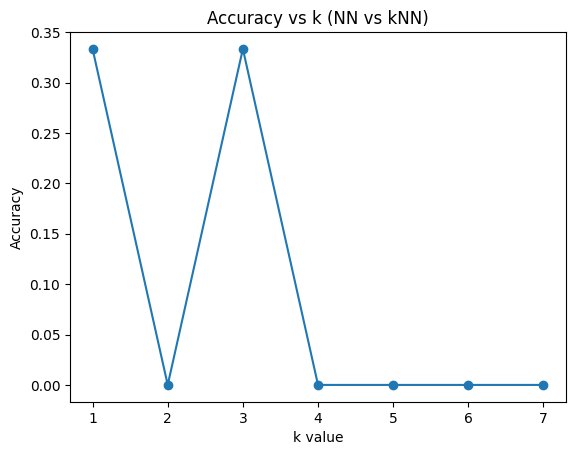

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# Load data
df = pd.read_excel("Lab Session Data.xlsx", sheet_name="Purchase data")

X = df[['Candies (#)', 'Mangoes (Kg)', 'Milk Packets (#)']].values
y = df['Payment (Rs)'].apply(
    lambda x: "RICH" if x > 200 else "POOR"
).values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3
)

accuracy = []

print("A11 Result")
print("----------")
print("Accuracy for different values of k:")

# k should not exceed number of training samples
max_k = len(X_train)

for k in range(1, max_k + 1):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    acc = knn.score(X_test, y_test)
    accuracy.append(acc)
    print("k =", k, "Accuracy =", acc)

# Plot Accuracy vs k
plt.plot(range(1, max_k + 1), accuracy, marker='o')
plt.xlabel("k value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs k (NN vs kNN)")
plt.show()


In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

# Load data
df = pd.read_excel("Lab Session Data.xlsx", sheet_name="Purchase data")

X = df[['Candies (#)', 'Mangoes (Kg)', 'Milk Packets (#)']].values
y = df['Payment (Rs)'].apply(lambda x: "RICH" if x > 200 else "POOR").values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# Train kNN (k = 3)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

# ---------------- A12 ----------------
print("A12 Result")
print("---------")
print("Confusion Matrix:")

cm = confusion_matrix(y_test, y_pred)
print(cm)

# ---------------- A13 ----------------
print("\nA13 Result")
print("---------")

tp = cm[1][1]
tn = cm[0][0]
fp = cm[0][1]
fn = cm[1][0]

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1_score = 2 * precision * recall / (precision + recall)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1_score)

# ---------------- A14 ----------------
print("\nA14 Result")
print("---------")
print("Matrix Inversion Technique Result:")

y_numeric = np.array([1 if label == "RICH" else 0 for label in y])
weights = np.linalg.pinv(X) @ y_numeric

print("Weight vector:", weights)


A12 Result
---------
Confusion Matrix:
[[1 0]
 [2 0]]

A13 Result
---------
Accuracy: 0.3333333333333333
Precision: nan
Recall: 0.0
F1 Score: nan

A14 Result
---------
Matrix Inversion Technique Result:
Weight vector: [-0.0196597   0.26431172  0.04554979]


/var/folders/1t/zc__jdp11296d8v4ncdgyn_w0000gn/T/ipykernel_12494/1071070737.py:40: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)
